## 📊 Data Explanation

Each row is one vessel's movement during **one hour** (not one fishing trip).

| # | Column | Description | Example |
|---|--------|-------------|---------|
| 1 | `part_dt` | Date (YYYYMMDD) | `20260101` |
| 2 | `rfid_id` | Boat ID, identifies which ship the track belongs to | `3100****` |
| 3 | `rfid_time` | Hour of the day, 0 to 23 (3 means 03:00 to 03:59) | `3` |
| 4 | `geom` | The vessel's path during that hour, as a MULTILINESTRING in WKT format | `MULTILINESTRING((128.545 34.777, ...))` |
| 5 | `fishing_code` | Fishing method, the target label (**Train only**) | `자망` |

> ⚠️ Coordinates in `geom` are in **(longitude latitude)** order.

### 🎯 Target classes (`fishing_code`)

| Class | Meaning |
|-------|---------|
| 연안복합 | Coastal composite |
| 자망 | Gillnet |
| 통발 | Trap / pot |
| 채낚기연승낚시 | Squid jigging / longline / hook-and-line |


## Competition Requirements: Fishing Classification & Anomaly Detection
|  | **Task 1** | **Task 2** |
|---|---|---|
| **Goal** | **"What kind of fishing is this?"**<br>**"이것은 어떤 종류의 어업인가?"** | **"Is this movement unusual/dangerous?"**<br>**"이 움직임은 비정상적이거나 위험한가?"** |
| **Training label given** | `fishing_code`, for known boats<br>`fishing_code`, 알려진 선박에 대해 제공됨 | Accident vessel ID + accident time, for SOME boats only<br>일부 선박에 대해서만 사고 선박 ID + 사고 시간이 제공됨 |
| **What you build** | A classifier using features you extract from `geom`<br>`geom`에서 추출한 특징을 사용하는 분류 모델 | An anomaly-scoring method comparing new tracks to learned "normal" patterns<br>새로운 이동 경로를 학습된 "정상" 패턴과 비교하여 이상 점수를 계산하는 방법 |
| **Test input** | Track only, no label<br>이동 경로만 제공, 라벨 없음 | Track only, no accident markers<br>이동 경로만 제공, 사고 표시 없음 |
| **Test output** | Predicted fishing method<br>예측된 어업 방식 | A continuous Anomaly Score per time period<br>시간 구간별 연속적인 이상 점수 |

In [14]:

# Import Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)   # keeps the minus sign from breaking

RAW_PATH = "../data/raw/fishing_vessel/mock_train.csv"
df = pd.read_csv(RAW_PATH)

print("Shape:", df.shape)
df.head()


Shape: (240, 5)


,part_dt,rfid_id,rfid_time,geom,fishing_code
0,20260101,31000001,6,"MULTILINESTRING ((128.066000 34.680474, 128.05...",자망
1,20260101,31000001,7,"MULTILINESTRING ((128.049029 34.746177, 128.05...",자망
2,20260101,31000001,8,"MULTILINESTRING ((128.065301 34.687698, 128.04...",자망
3,20260101,31000001,9,"MULTILINESTRING ((128.042414 34.695674, 128.02...",자망
4,20260101,31000001,10,"MULTILINESTRING ((128.082742 34.723702, 128.10...",자망


In [5]:
print(df["fishing_code"].value_counts())            # class balance
print(df["rfid_id"].nunique())                      # number of vessels
print(df.groupby("rfid_id")["fishing_code"].nunique().value_counts())  # 1 = each vessel has one label
print(df["geom"].isna().sum())                      # missing tracks

fishing_code
자망         60
통발         60
연안복합       60
채낚기연승낚시    60
Name: count, dtype: int64
20
fishing_code
1    20
Name: count, dtype: int64
0


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

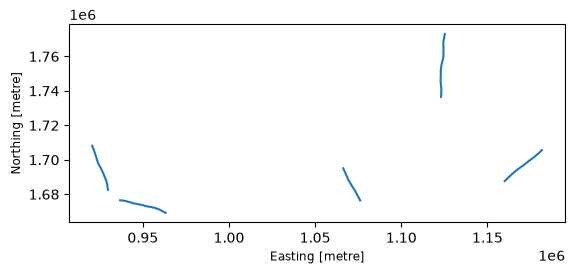

In [11]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

df["geometry"] = df["geom"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
gdf = gdf.to_crs("EPSG:5179")   # Korean metric CRS, so lengths are in meters
gdf[gdf.fishing_code == "연안복합"].sample(5).plot()

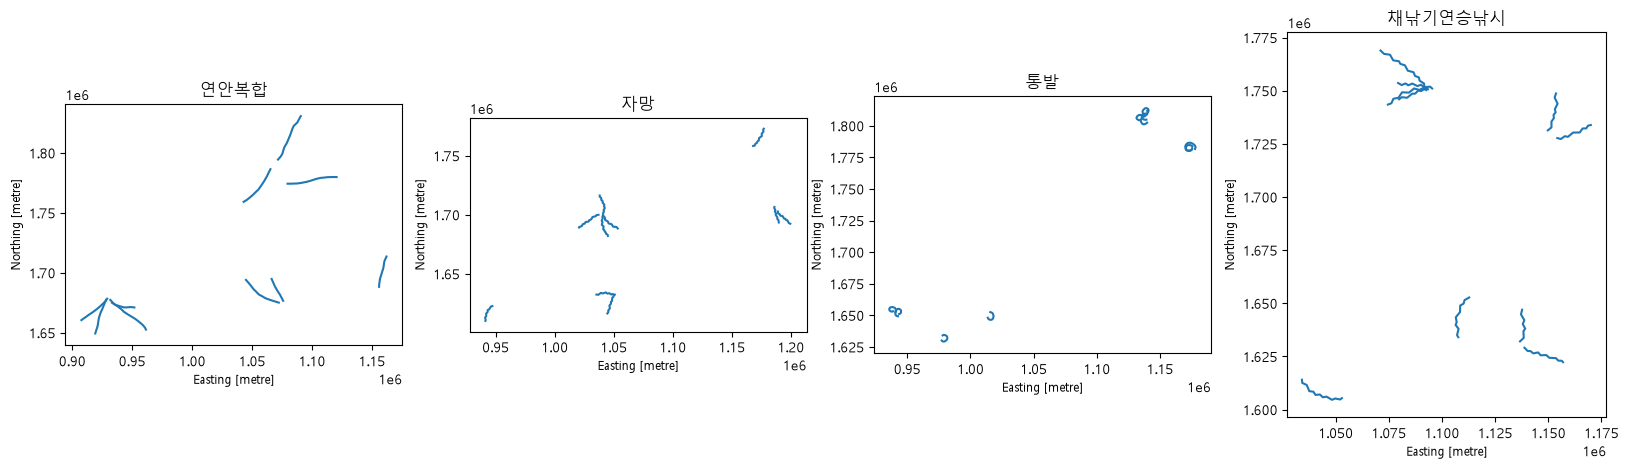

In [ ]:
import matplotlib.pyplot as plt

classes = ["연안복합", "자망", "통발", "채낚기연승낚시"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, c in zip(axes, classes):
    gdf[gdf.fishing_code == c].sample(10, random_state=0).plot(ax=ax)
    ax.set_title(c)
plt.show()